# Deviance-Guide UOT Immune Cells with Regularization
The main limitations of this OT-based approach is the long computation time. Regularization is a known approach to speed up these calculations. Thus, we'll see how regularization affects results.

In [3]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [2]:
### Directories and Files ###
root = '../../../../../'
metadata_dir = f"{root}Data/sc_data/cell_types.tsv"
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data' # Importing was not working with relative root+'..' approach, so replace with local data
save_dir = f"{root}Generated Data/Single-to-single/sc_uot_clustering/OT/DevianceSelection/sinkhorn"

In [5]:
### Imports ###
import sys
import numpy as np
import pandas as pd
import cooler
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from umap import UMAP
from time import perf_counter
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, hic_ot_bulk_deviance, long_transform, ot_mass_deviance, generate_clustermap, generate_marginal_plot

In [6]:
### Pre-importing metadata ###
metadata_df = pd.read_csv(metadata_dir, sep="\t")
metadata_df

,cell_name,cell_type
0,arc_pair_7,T cells
1,arc_pair_18,CD4+ T cells
2,arc_pair_31,CD4+ T cells
3,arc_pair_56,T cells
4,arc_pair_57,CD8+ T cells
...,...,...
8058,arc_pair_736107,T cells
8059,arc_pair_736132,CD8+ T cells
8060,arc_pair_736144,CD8+ T cells
8061,arc_pair_736230,Monocytes


## Helper Functions

### Data Handling

In [20]:
def subset_clr_data(
        data_dir: str, 
        metadata: pd.DataFrame, 
        count: int=20, 
        seed: int=42
        ) -> list[cooler.Cooler]:
    '''
        Takes a directory of cooler files, selects the number of cells specified
        by count per cell type given in metadata.

        Function is specific to formatting in this notebook.

        Parameters
        ----------
        data_dir : str
            The path to the folder containing the data.
        metadata : pd.DataFrame
            Metadata dataframe providing a mapping for file to cell
            line.
        count : int
            Number of cells to import per cell line.
            Default = 20.
        seed : int
            Seed used for randomization
            Default = 42.

        Returns
        -------
        clrs_subset : list(cooler.Cooler)
            List of coolers from specified subset.
    '''
    # Selecting files
    sampled_files = (
        metadata.groupby('cell_type')
                .apply(lambda x: x.sample(
                    n=min(len(x), count),
                    replace=False,
                    random_state=seed
                ))
                .reset_index(drop=True)
    )
    samples = list(sampled_files["cell_name"])

    # Importing coolers
    clrs_subset = import_cool_dir(data_dir, include=samples)
    return clrs_subset

def generate_ot_data(
        reg_m: float = 10, 
        top_number : int = 250,
        count: int=20, 
        seed: int=42,
        reg: float|None=None
        ) -> tuple[pd.DataFrame, float]:
    '''
        Generates pair-wise OT comparison data for the immune cell data
        using the provided arguments. Additionally, keeps track of computation
        time.

        Function is specific to this notebook.

        Parameters
        ----------
        reg_m : float
            Unbalanced parameter to use.
            Default = 10.
        top_number : int
            Top number of contacts to use based on deviance.
            Default = 250.
        cell_count : int
            The top number of cells to be used.
            Default = 20.
        seed : int
            Seed for subsetting.
            Default = 42.
        reg : float | None
            Regularization parameter for Sinkhorn regularization.
            Default = None, uses no regularization.

        Returns
        -------
        ot_results : pd.DataFrame
            Pandas dataframe with the desired results.
    '''
    # Subsetting
    clrs = subset_clr_data(data_dir, metadata_df, count, seed)
    
    # OT
        # Starting timer
    start_time = perf_counter()

        # Calculations
    ot_results = hic_ot_bulk_deviance(
        clrs,
        "chr1",
        top_number,
        "max",
        reg_m,
        reg
    )
    
        # Stopping timer
    end_time = perf_counter() - start_time

        # Saving results
    ot_results.to_csv(f'{save_dir}/IMMUNE_CELLS_DEVIANCE_unbalanced_reg_m={reg_m}_cluster_top={top_number}_count={count}_seed={seed}_reg={reg}.csv')

    return ot_results, end_time

def load_ot_data_numpy(
        top_number : int,
        reg_m: float,
        count: int=20,
        seed: int=42,
        reg: float|None=None,
        condense: str="full"
        ) -> tuple[np.ndarray, list[str]]:
    
    '''
        Loads OT results for immune cell data as an ndarray
        of OT results and a list of cell types.

        This function is very specific to this notebook.

        Parameters
        ----------
        top_number : int
            Top number of contacts used.
        reg_m : float
            Unbalanced parameter used.
        count : int
            Number of cells per cell type used for analysis.
            Default = 20.
        seed : int
            Seed used to select data.
            Default = 42.
        reg : float | None
            Regularization parameter for Sinkhorn regularization.
            Default = None, uses no regularization.
        condense : str
            Controls the extent to which the cell types are condensed.
            Options include "full", "half" and "not".
            Default = "full.

        Returns
        -------
        ot_ndarray : np.ndarray
            OT results in ndarray form.
        cell_types : list[str]
            List of cell types in the same order as original
            data.
    '''
    # File
    file = f"{save_dir}/IMMUNE_CELLS_DEVIANCE_unbalanced_reg_m={reg_m}_cluster_top={top_number}_count={count}_seed={seed}_reg={reg}.csv"


    # Importing file
    ot_df_matrix = pd.read_csv(file, index_col=0)

    # Converting to ndarray
    ot_ndarray = ot_df_matrix.to_numpy()

    # Fetching cell types   
    cell_types = []
    for cell in ot_df_matrix.index:
        specific_type = metadata_df[metadata_df['cell_name'] == cell]['cell_type'].values[0]
        
        if condense == "full":
            lymphoids = ['B cells', 'CD8+ T cells', 'CD4+ T cells', 'T cells', 'NK cells']
            myeloids = ['Dendritic cells', 'Monocytes', 'Neutrophils']

            if specific_type in lymphoids:
                cell_types.append("Lymphoid")
            elif specific_type in myeloids:
                cell_types.append("Myeloid")
            else:
                cell_types.append("Progenitors")
            
        elif condense == "half":
            t_cells = ['CD8+ T cells', 'CD4+ T cells', 'T cells']
            myeloids = ['Dendritic cells', 'Monocytes', 'Neutrophils']

            if specific_type in t_cells:
                cell_types.append("T cells")
            elif specific_type in myeloids:
                cell_types.append("Myeloid cells")
            else:
                cell_types.append(specific_type)

        elif condense == "not":
            cell_types.append(specific_type)
        else:
            raise ValueError(f"Condensation type not recognized: {condense}")

    return ot_ndarray, cell_types

### Visualizing

In [33]:
def generate_clustering(
        data : np.ndarray,
        cell_lines : list[str],
        title : str,
        ax
        ):
    '''
        Draws clustering of the data to the provided Axes object
        using UMAP.

        Parameters
        ----------
        data : np.ndarray
            OT data in ndarray form.
        cell_lines : list[str]
            List of cell lines corresponding to the cell order in
            the data.
        title : str
            Title for the panel
        ax
            Axes object to parse figure to
    '''
    vec = UMAP(n_components=2, random_state=42).fit_transform(data)
    xlab = "UMAP 1"
    ylab= "UMAP 2"

    # Figure
    sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_lines, ax=ax, s=20, linewidth=0)
    handles, labels = ax.get_legend_handles_labels()
    labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
    ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=1)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    return

## Generating Data

In [ ]:
### Generating multiple regularization values ###
reg_list = [None, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
time_list = []

for reg in reg_list:
    print("Starting OT for reg =", reg)
    _, time = generate_ot_data(0.1, 250, 40, 42, reg)
    time_list.append(time)

Starting OT for reg = 0.01


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_12887/603732694.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Starting OT (0/85849)
Starting OT (1/85849)
Starting OT (2/85849)
Starting OT (3/85849)
Starting OT (4/85849)
Starting OT (5/85849)
Starting OT (6/85849)
Starting OT (7/85849)
Starting OT (8/85849)
Starting OT (9/85849)
Starting OT (10/85849)
Starting OT (11/85849)
Starting OT (12/85849)
Starting OT (13/85849)
Starting OT (14/85849)
Starting OT (15/85849)
Starting OT (16/85849)
Starting OT (17/85849)
Starting OT (18/85849)
Starting OT (19/85849)
Starting OT (20/85849)
Starting OT (21/85849)
Starting OT (22/85849)
Starting OT (23/85849)
Starting OT (24/85849)
Starting OT (25/85849)
Starting OT (26/85849)
Starting OT (27/85849)
Starting OT (28/85849)
Starting OT (29/85849)
Starting OT (30/85849)
Starting OT (31/85849)
Starting OT (32/85849)
Starting OT (33/85849)
Starting OT (34/85849)
Starting OT (35/85849)
Starting OT (36/85849)
Starting OT (37/85849)
Starting OT (38/85849)
Starting OT (39/85849)
Starting OT (40/85849)
Starting OT (41/85849)
Starting OT (42/85849)
Starting OT (43/85849

In [45]:
### Saving times ###
times_dict = {
    "reg" : reg_list,
    "time" : time_list
}

times_df = pd.DataFrame.from_dict(times_dict)
times_df.to_csv(f'{save_dir}/uot_sc_devianceguided_reg_times.csv')

## Loading Data

In [46]:
### Loading data into dict per reg ###
data_dict_original = {}
data_dict_condensed = {}
data_dict_half = {}

for reg in reg_list:
    data_np_original = load_ot_data_numpy(250, 0.1, 40, 42, reg, "not")
    data_np_condensed = load_ot_data_numpy(250, 0.1, 40, 42, reg, "full")
    data_np_half = load_ot_data_numpy(250, 0.1, 40, 42, reg, "half")

    data_dict_original[reg] = data_np_original
    data_dict_condensed[reg]  = data_np_condensed
    data_dict_half[reg]  = data_np_half

In [47]:
### Loading times df ###
times_df = pd.read_csv(f'{save_dir}/uot_sc_devianceguided_reg_times.csv', index_col=0)
times_df

,reg,time
0,NaN,440.734290
1,0.010000,314.810763
2,0.001000,124.658165
3,0.000100,97.755116
4,0.000010,92.451497
5,0.000001,92.955578


## Visualizing

### Times

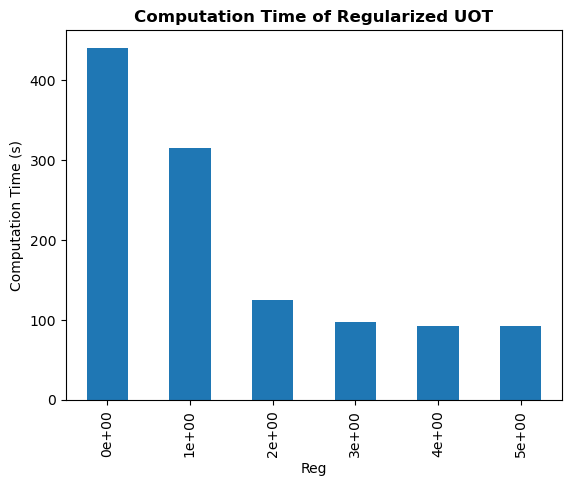

In [63]:
ax = times_df.plot.bar(
        x="reg", 
        y="time", 
        legend=False,
        ylabel="Computation Time (s)",
        xlabel="Reg")
plt.title("Computation Time of Regularized UOT", fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))

### UMAPS

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: Us

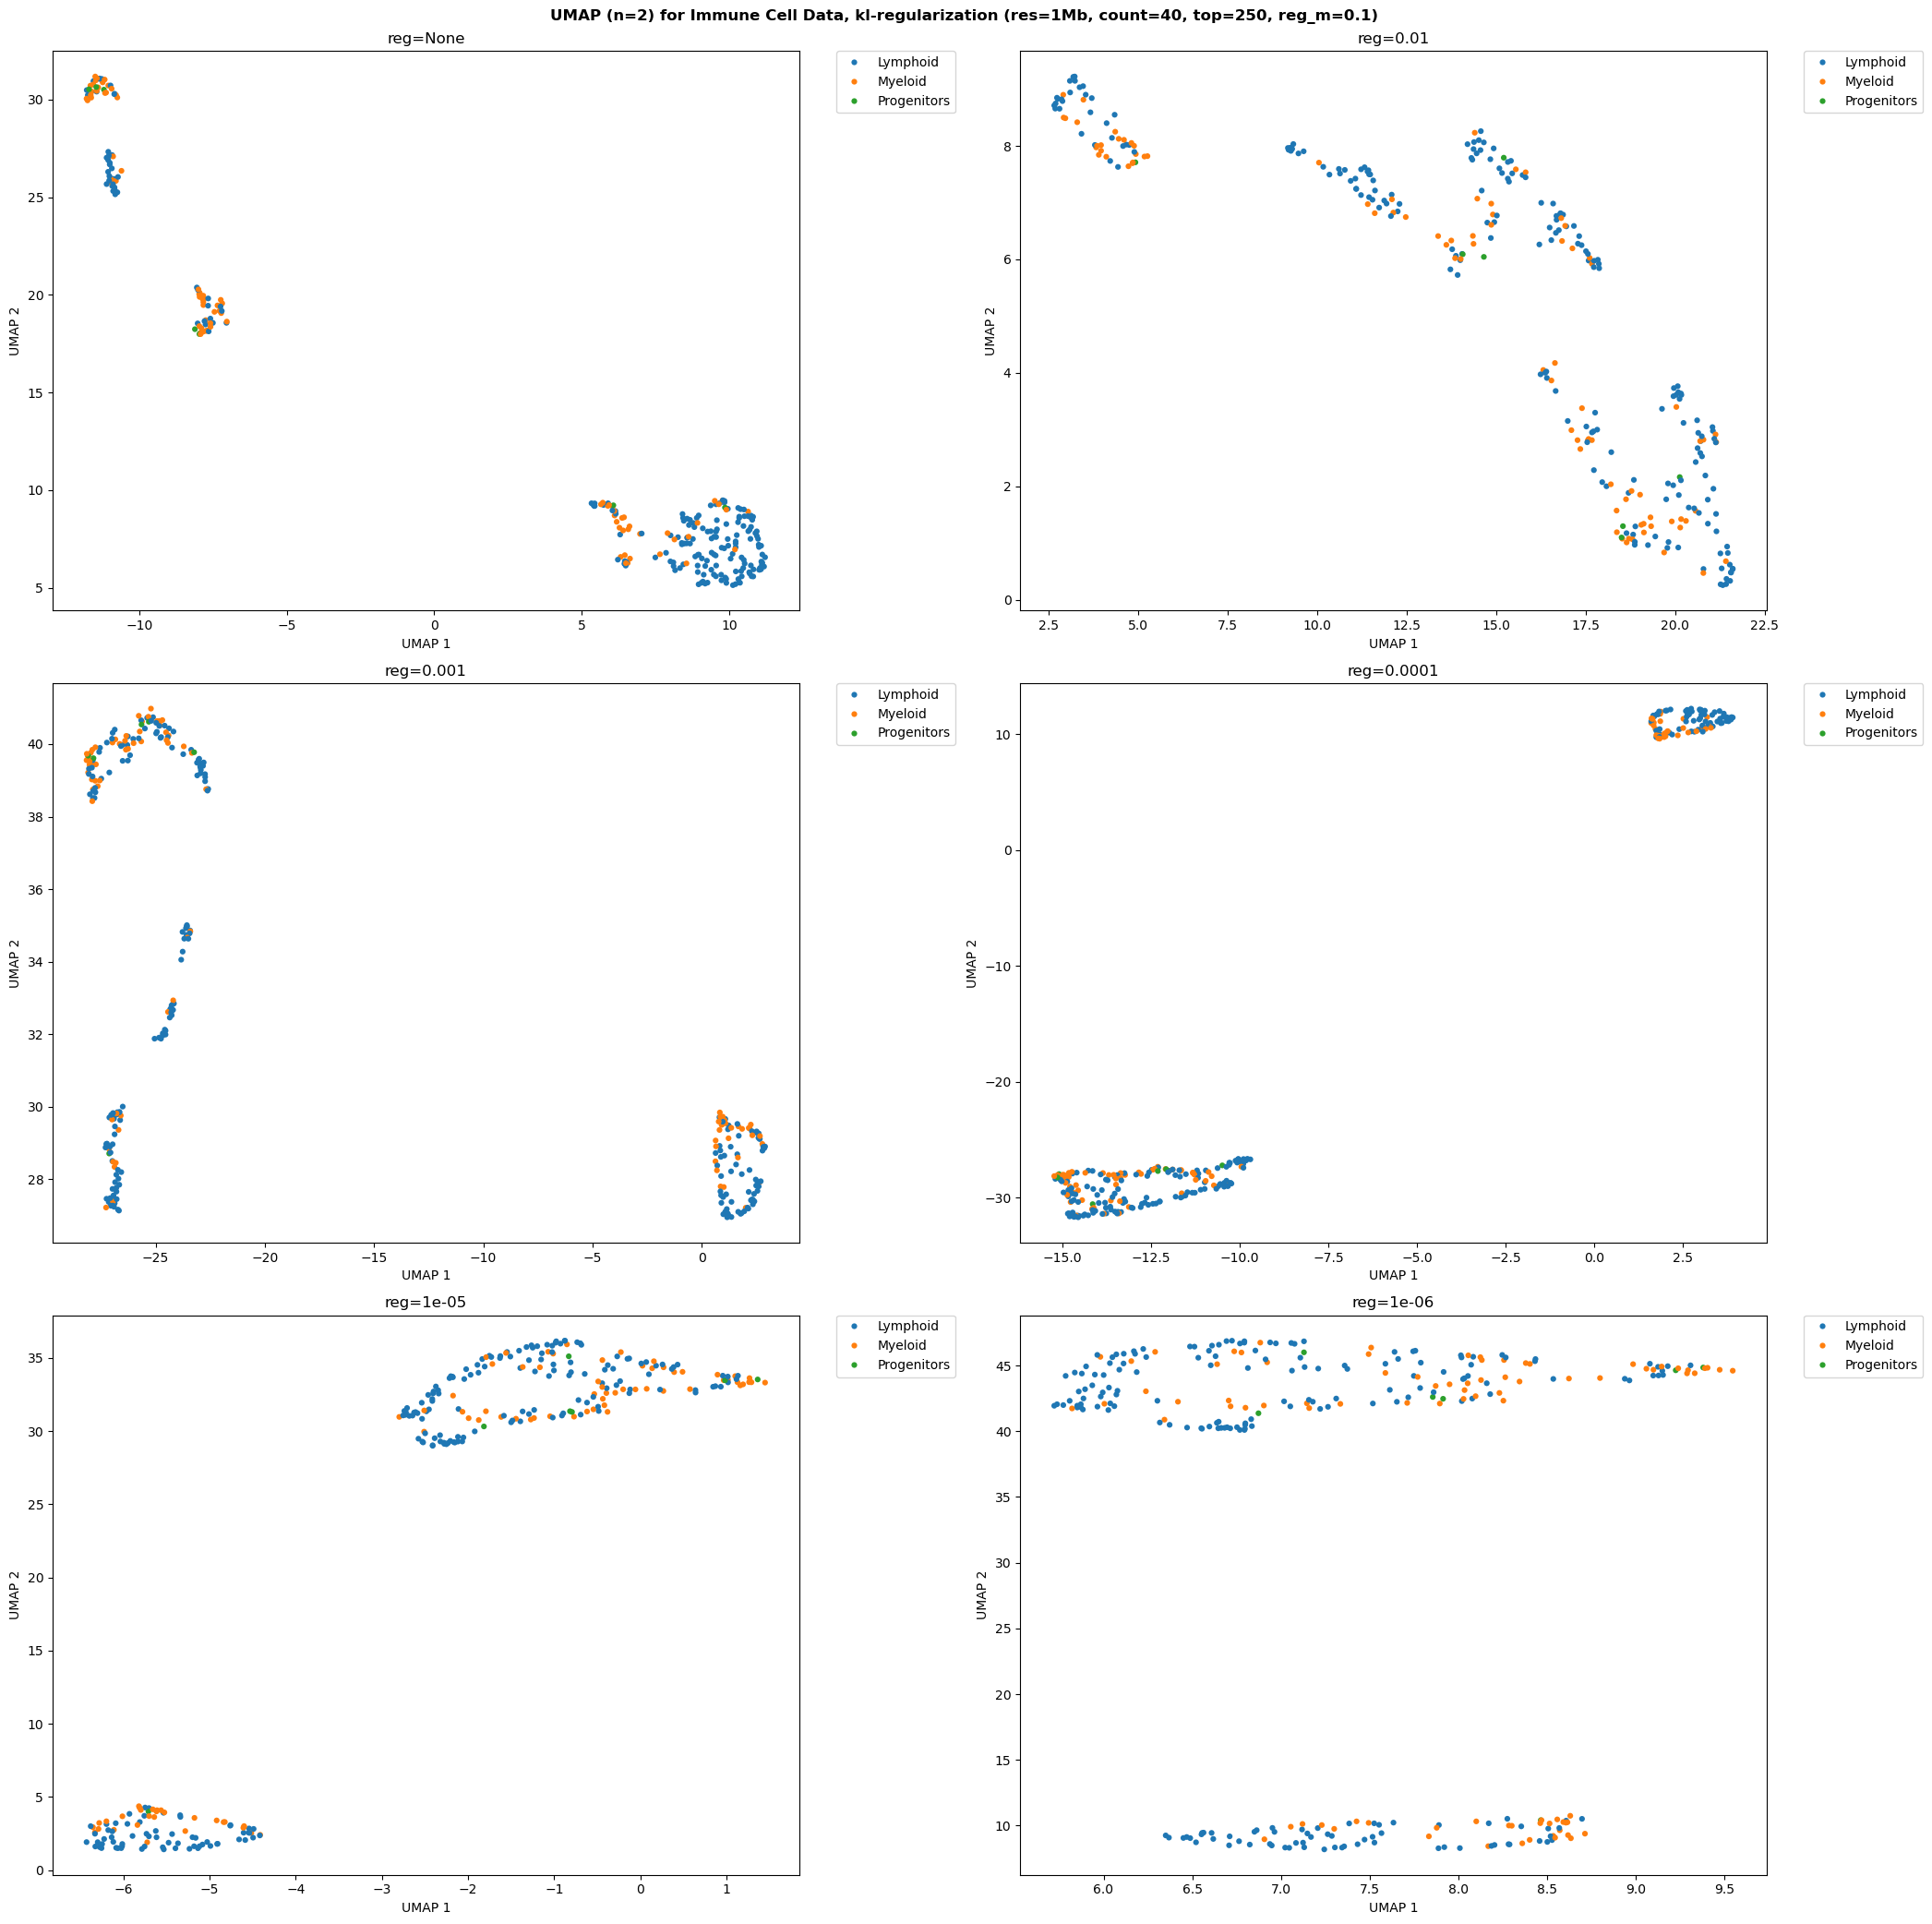

In [50]:
### Visualizing batched clustering, condensed ###
fig, ax = plt.subplots(3, 2, figsize=(21,21))
axes = ax.flatten()

    # Adding subpanels
for i, (reg, data) in enumerate(data_dict_condensed.items()):
    generate_clustering(data[0], data[1], f"reg={reg}", axes[i])

    # Adding titles
plt.suptitle("UMAP (n=2) for Immune Cell Data, kl-regularization (res=1Mb, count=40, top=250, reg_m=0.1)", fontweight="bold", y=0.99)
plt.tight_layout()

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: Us

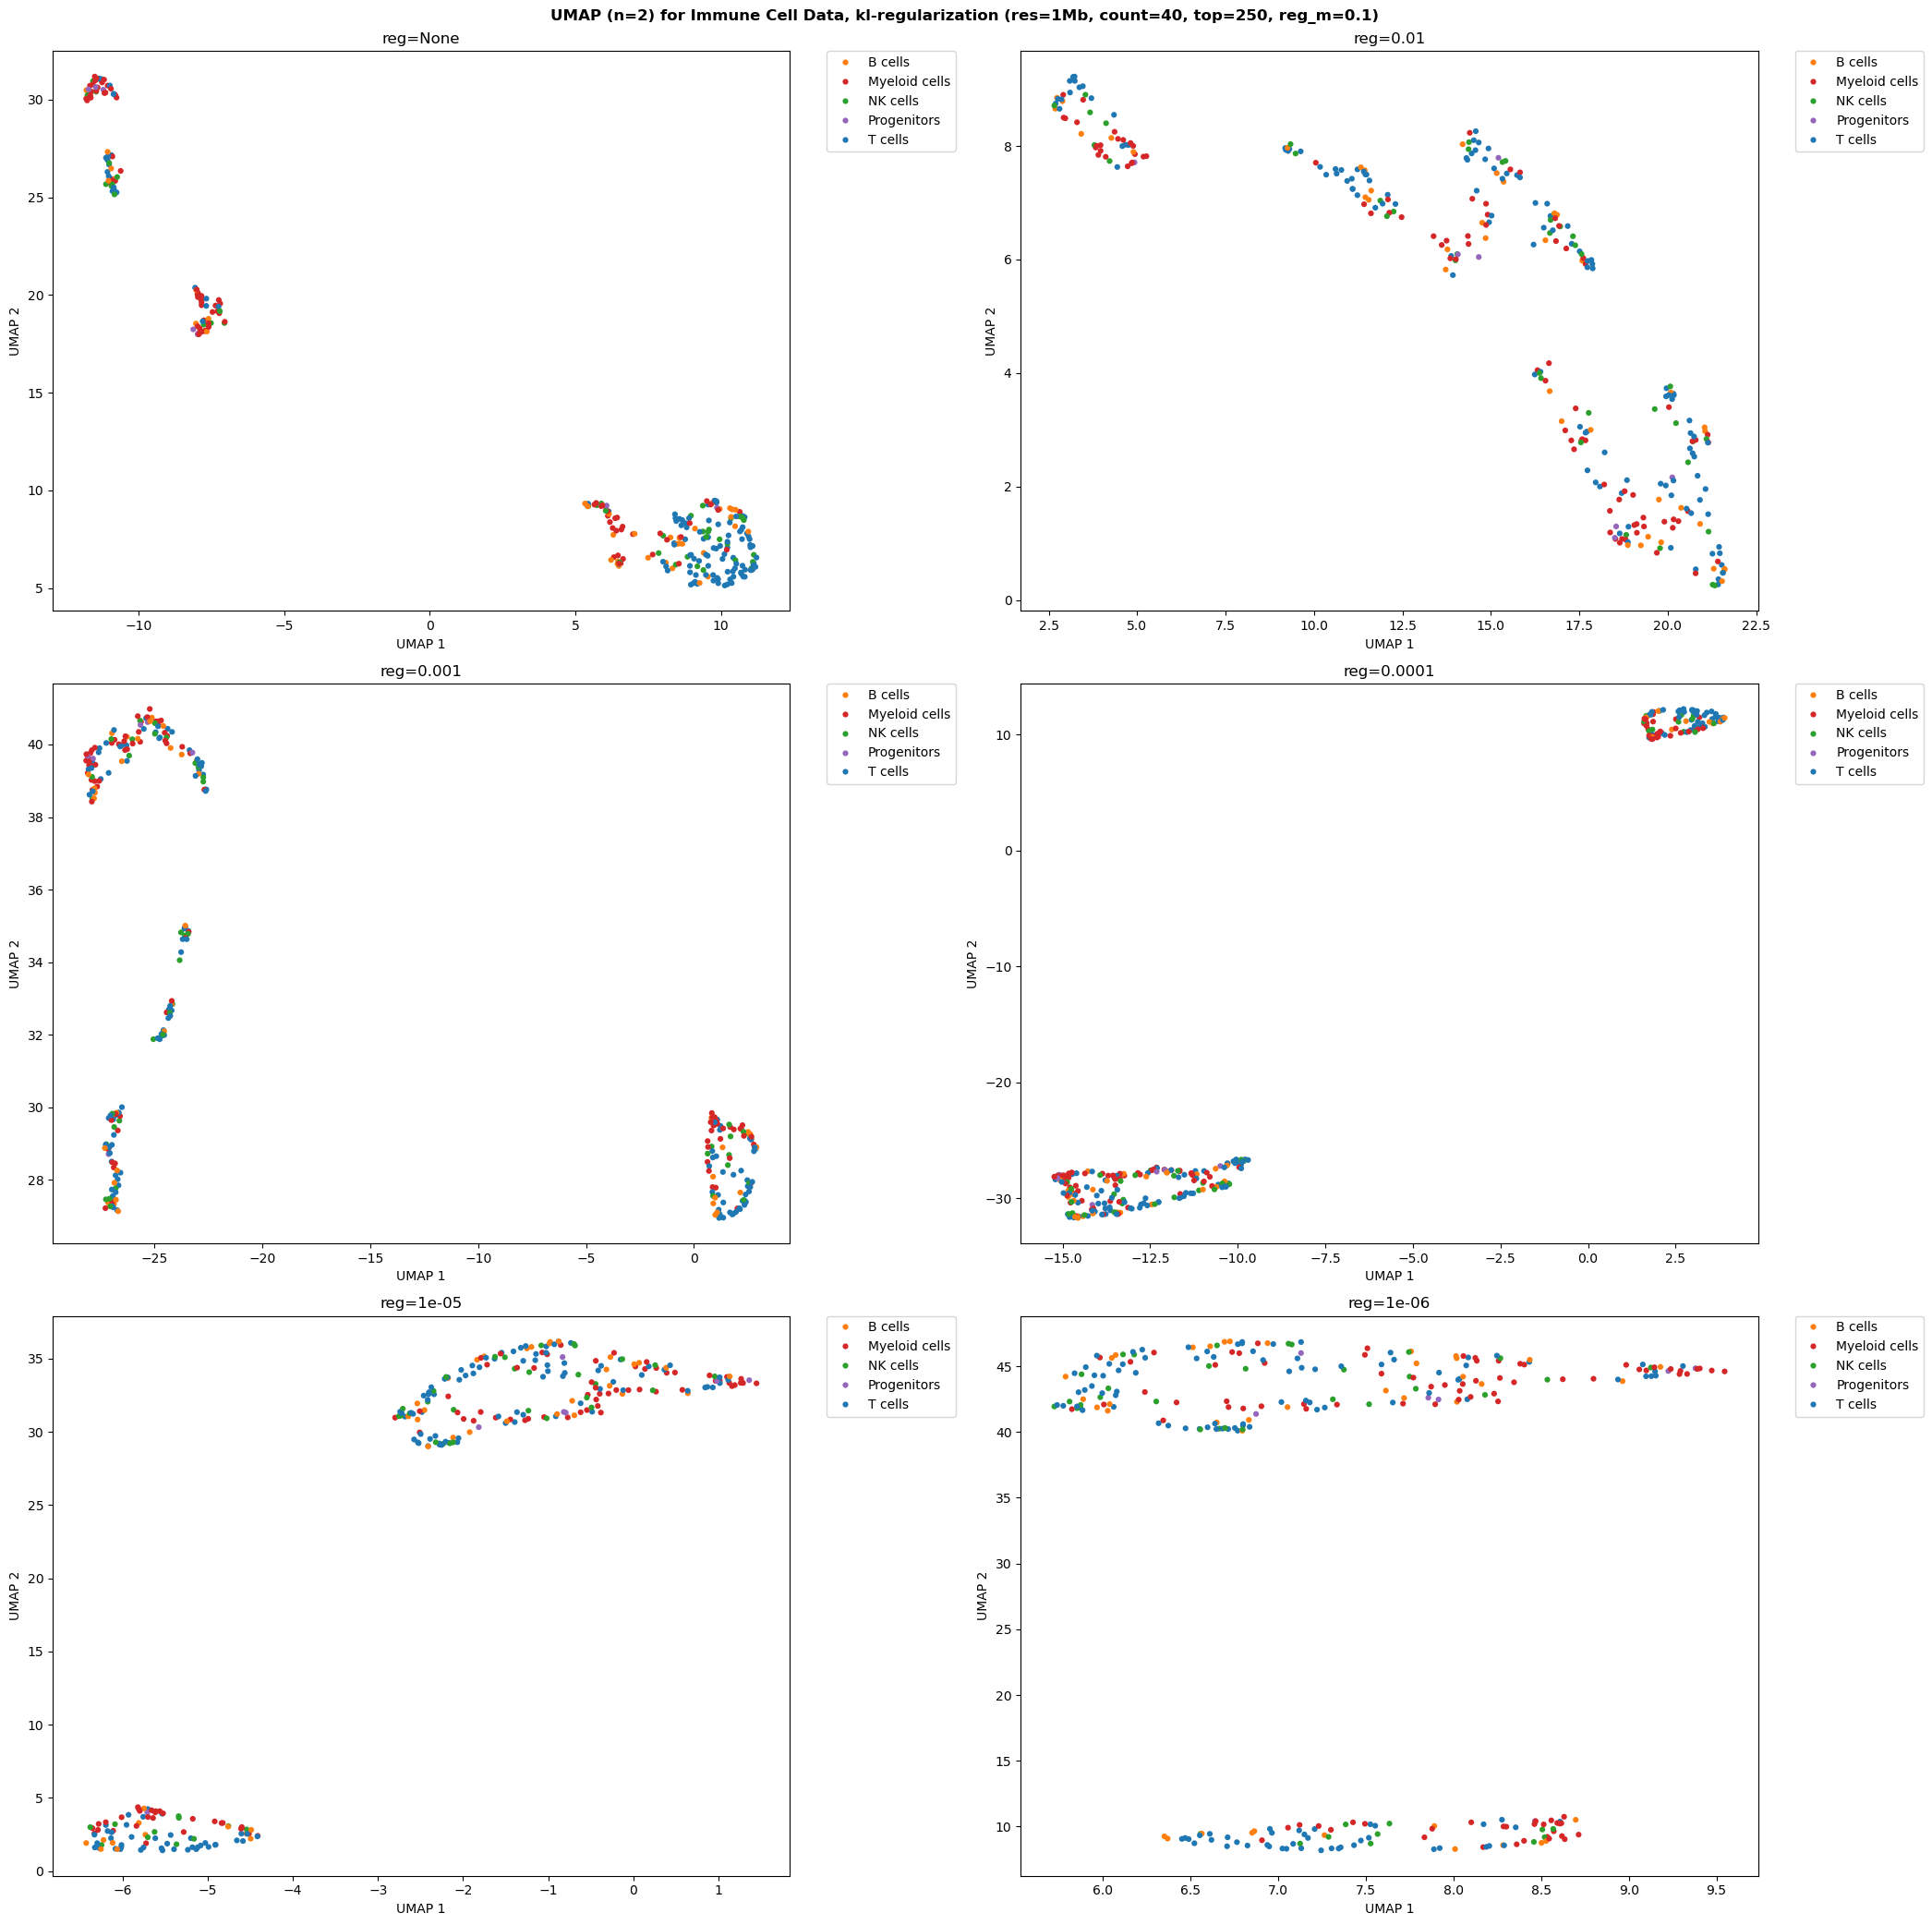

In [51]:
### Visualizing batched clustering, condensed ###
fig, ax = plt.subplots(3, 2, figsize=(21,21))
axes = ax.flatten()

    # Adding subpanels
for i, (reg, data) in enumerate(data_dict_half.items()):
    generate_clustering(data[0], data[1], f"reg={reg}", axes[i])

    # Adding titles
plt.suptitle("UMAP (n=2) for Immune Cell Data, kl-regularization (res=1Mb, count=40, top=250, reg_m=0.1)", fontweight="bold", y=0.99)
plt.tight_layout()

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/umap/umap_.py:1952: Us

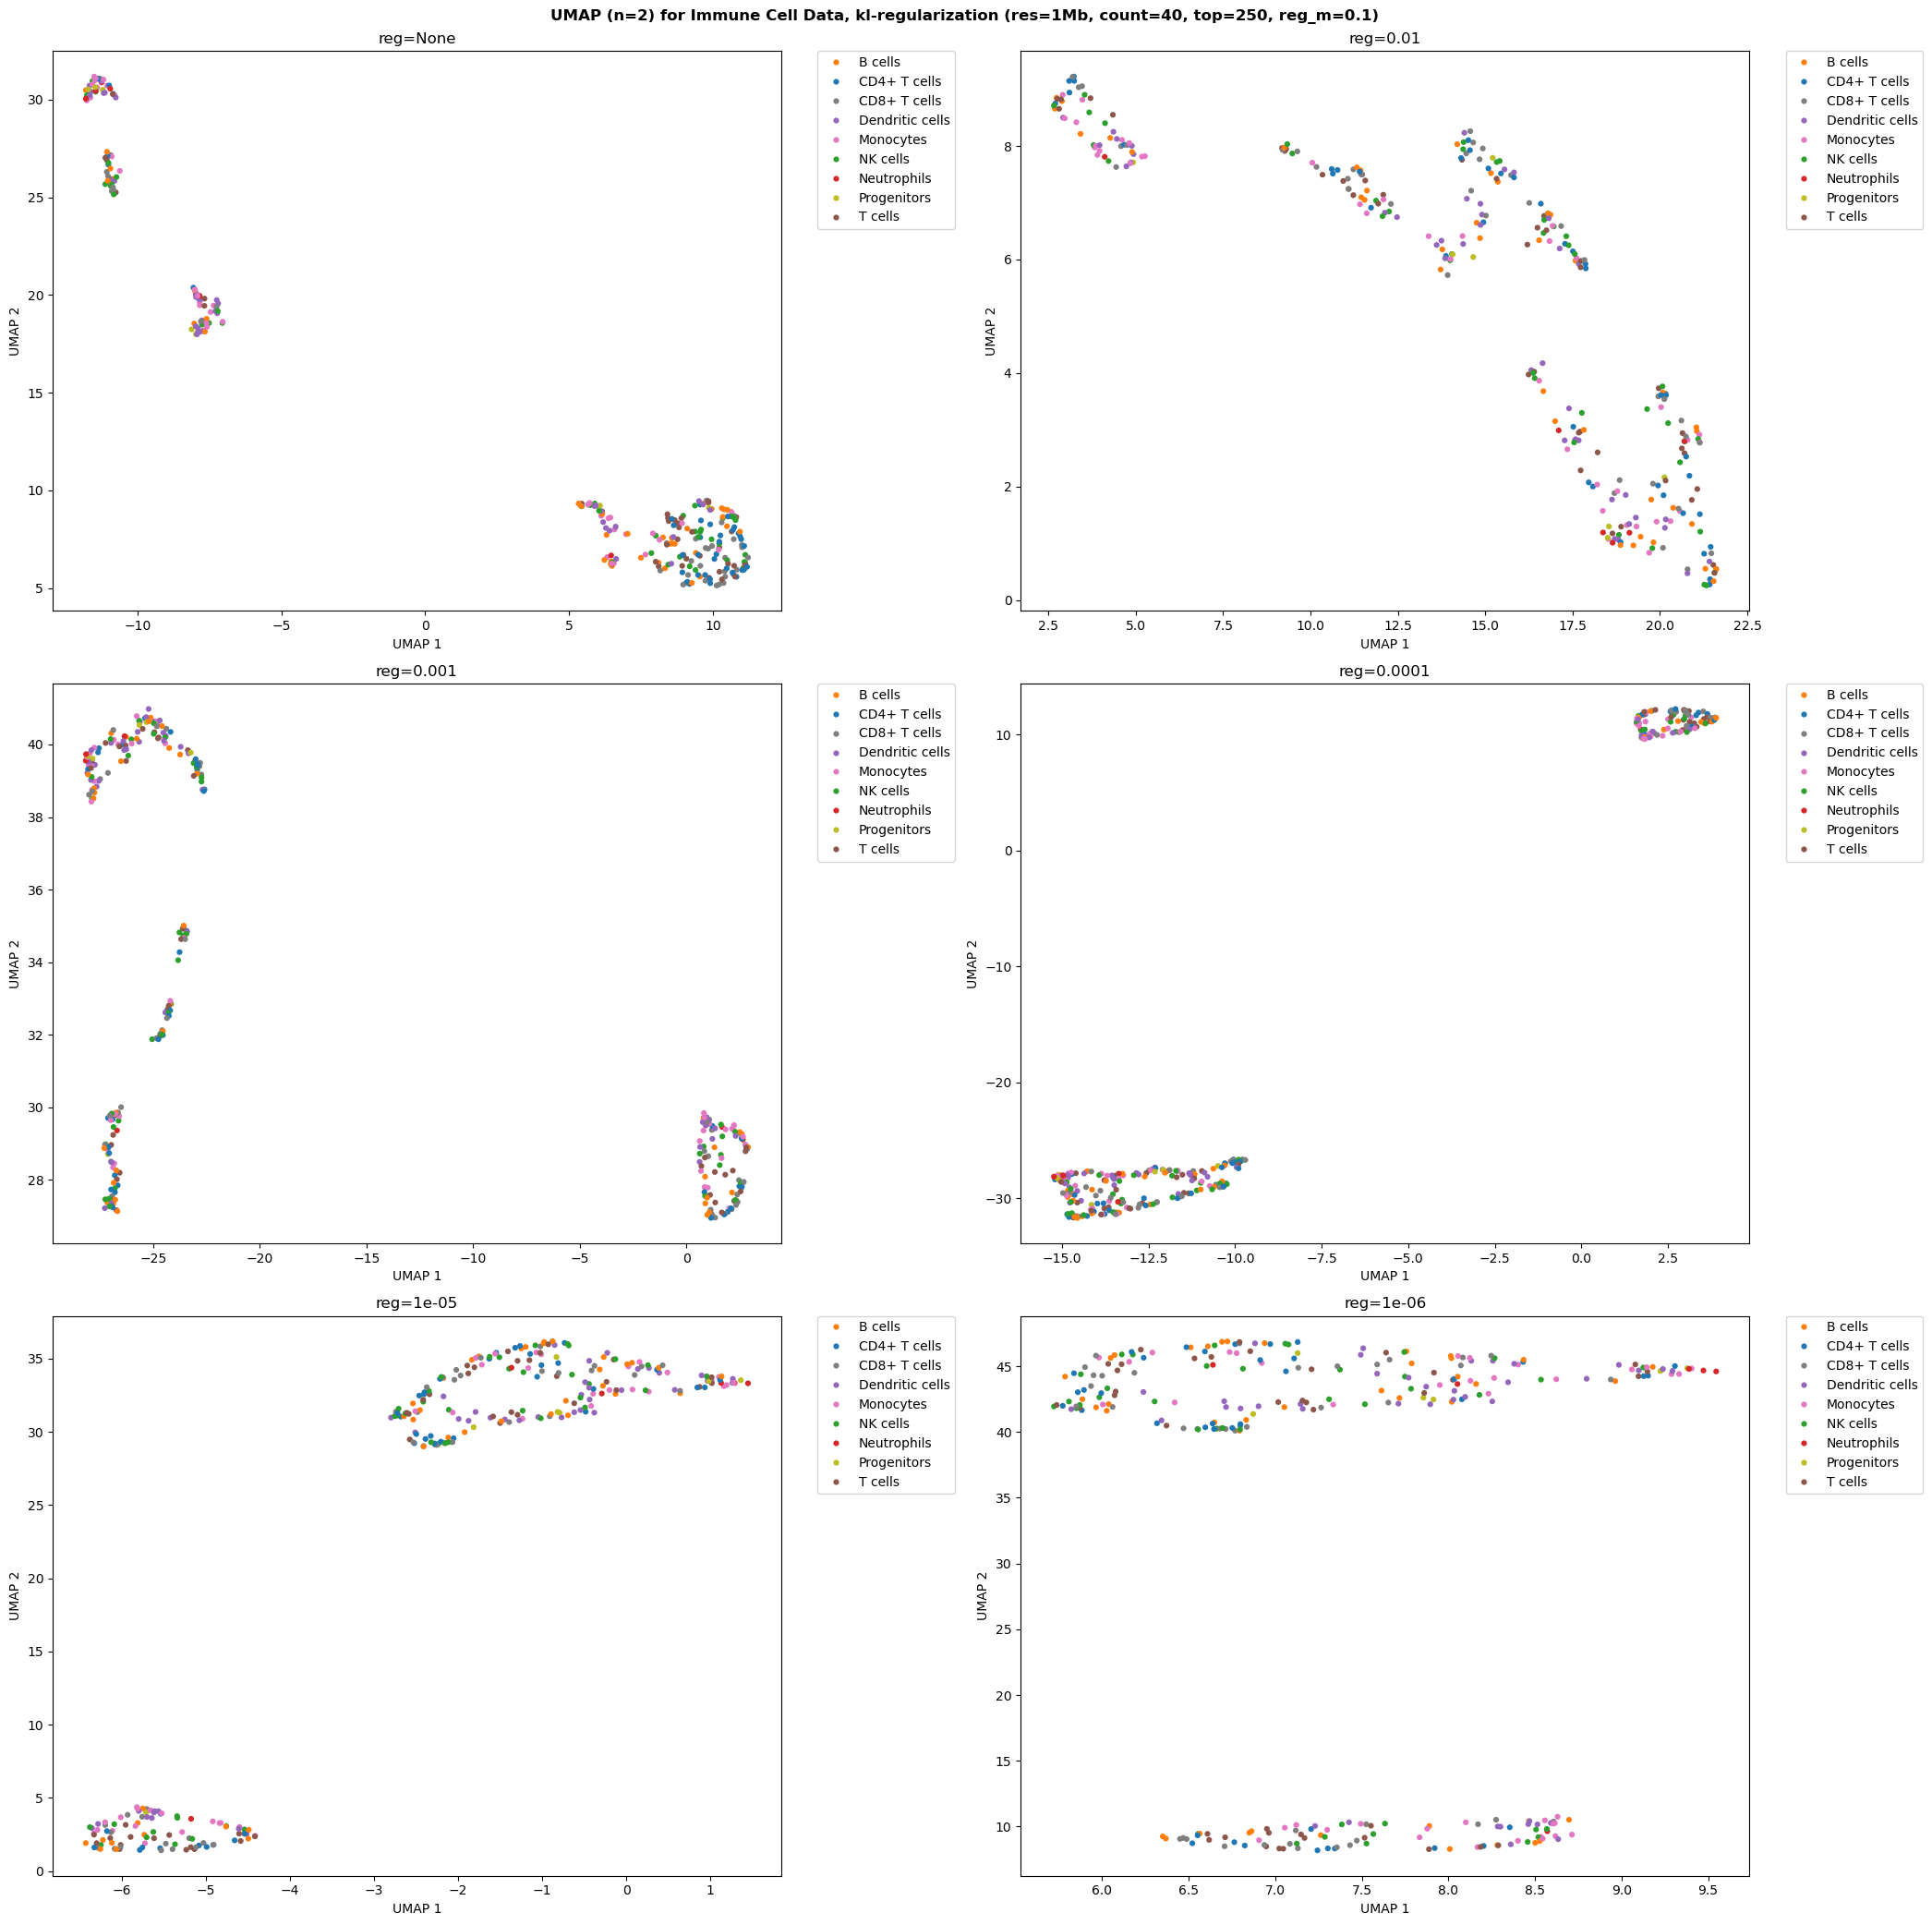

In [52]:
### Visualizing batched clustering, original ###
fig, ax = plt.subplots(3, 2, figsize=(21,21))
axes = ax.flatten()

    # Adding subpanels
for i, (reg, data) in enumerate(data_dict_original.items()):
    generate_clustering(data[0], data[1], f"reg={reg}", axes[i])

    # Adding titles
plt.suptitle("UMAP (n=2) for Immune Cell Data, kl-regularization (res=1Mb, count=40, top=250, reg_m=0.1)", fontweight="bold", y=0.99)
plt.tight_layout()

While clustering is different, it seems like there is still a perceivable clustering.

### Clustermaps

In [17]:
### Generate long-form dataframes ###
reg_list = [None, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
data_long_list = []
for reg in reg_list:
    file_name = f"{save_dir}/IMMUNE_CELLS_DEVIANCE_unbalanced_reg_m=0.1_cluster_top=250_count=40_seed=42_reg={reg}.csv"
    ot_data = pd.read_csv(file_name, index_col=0)
    data_long_list.append(long_transform(ot_data, metadata_df))
data_long_list[1]

,row_file,col_file,value,row_cell_type,col_cell_type,relationship
0,arc_pair_221519,arc_pair_221519,0.000000e+00,CD4+ T cells,CD4+ T cells,intra
1,arc_pair_564801,arc_pair_221519,1.027622e-11,B cells,CD4+ T cells,inter
2,arc_pair_161493,arc_pair_221519,2.752465e-11,NK cells,CD4+ T cells,inter
3,arc_pair_48468,arc_pair_221519,5.428802e-11,Neutrophils,CD4+ T cells,inter
4,arc_pair_439348,arc_pair_221519,1.610956e-11,Dendritic cells,CD4+ T cells,inter
...,...,...,...,...,...,...
85844,arc_pair_281486,arc_pair_723396,6.525502e-11,NK cells,Neutrophils,inter
85845,arc_pair_44188,arc_pair_723396,3.819906e-11,Dendritic cells,Neutrophils,inter
85846,arc_pair_553435,arc_pair_723396,6.986500e-11,B cells,Neutrophils,inter
85847,arc_pair_27275,arc_pair_723396,6.973166e-11,NK cells,Neutrophils,inter


/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


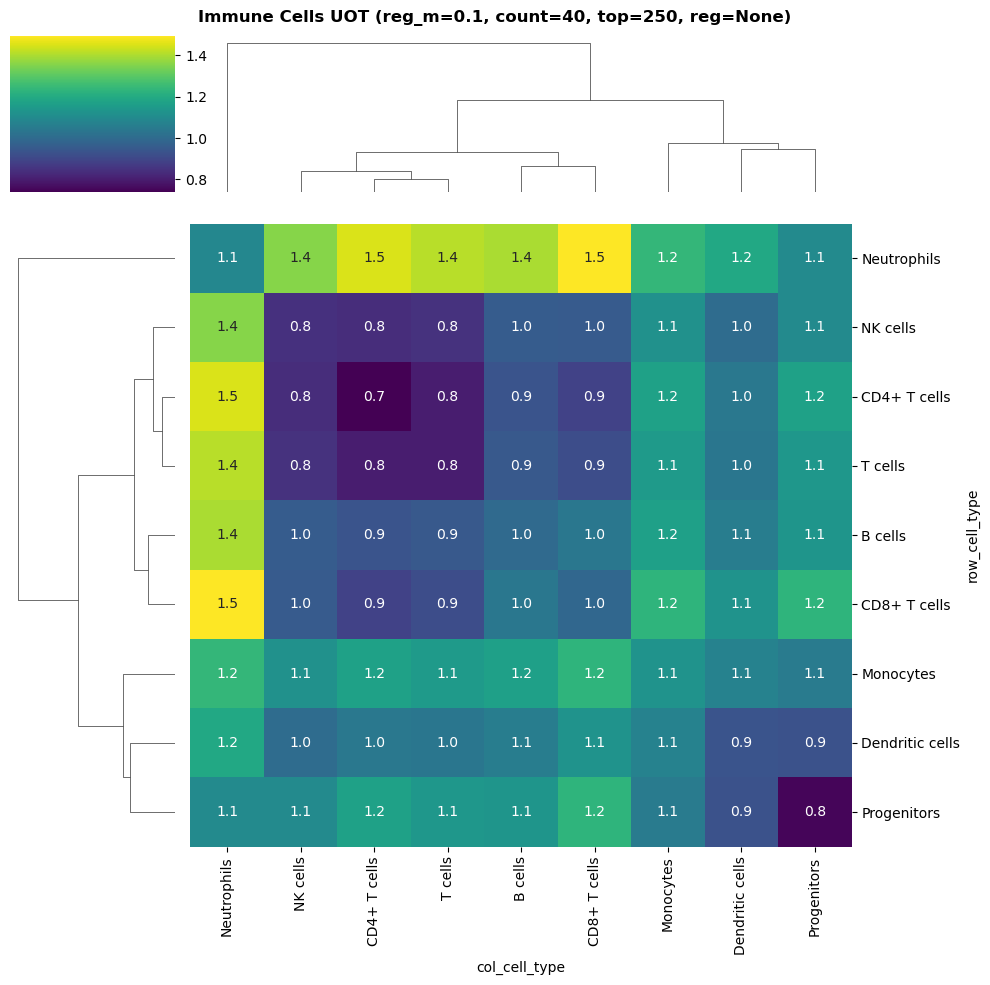

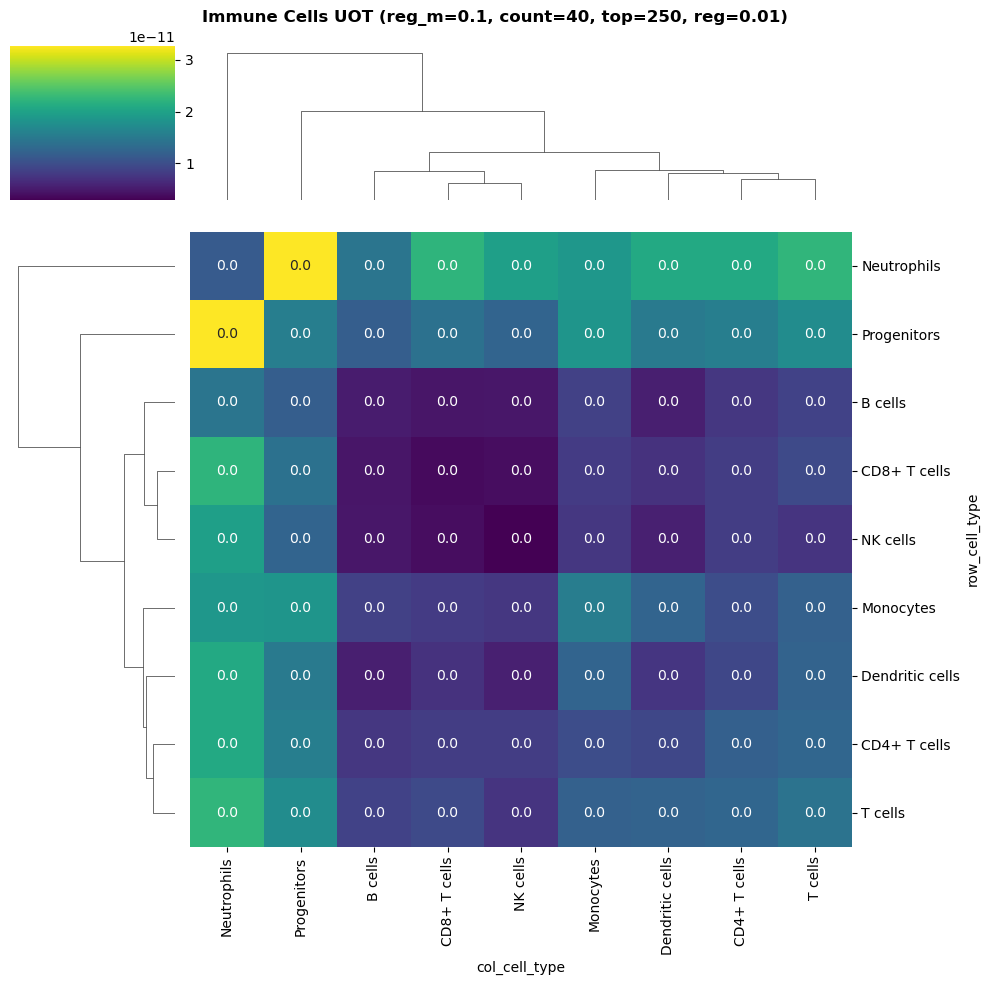

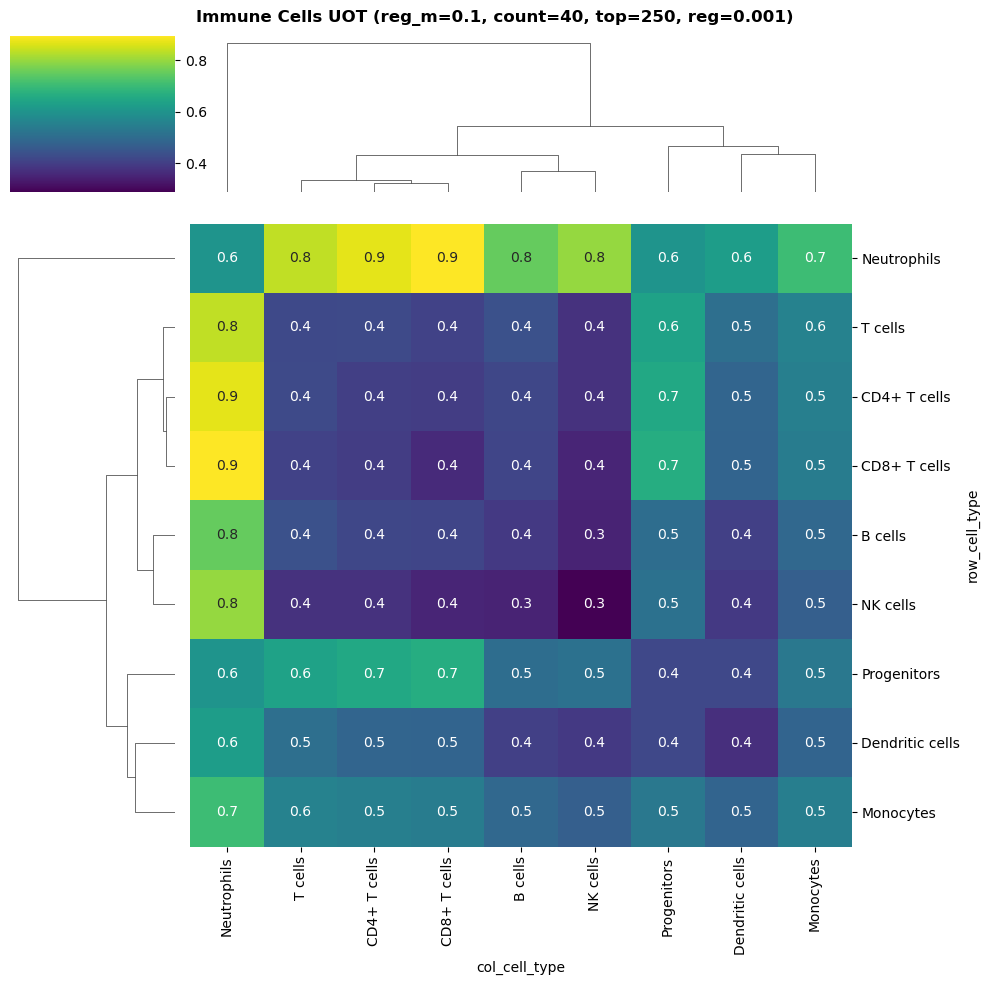

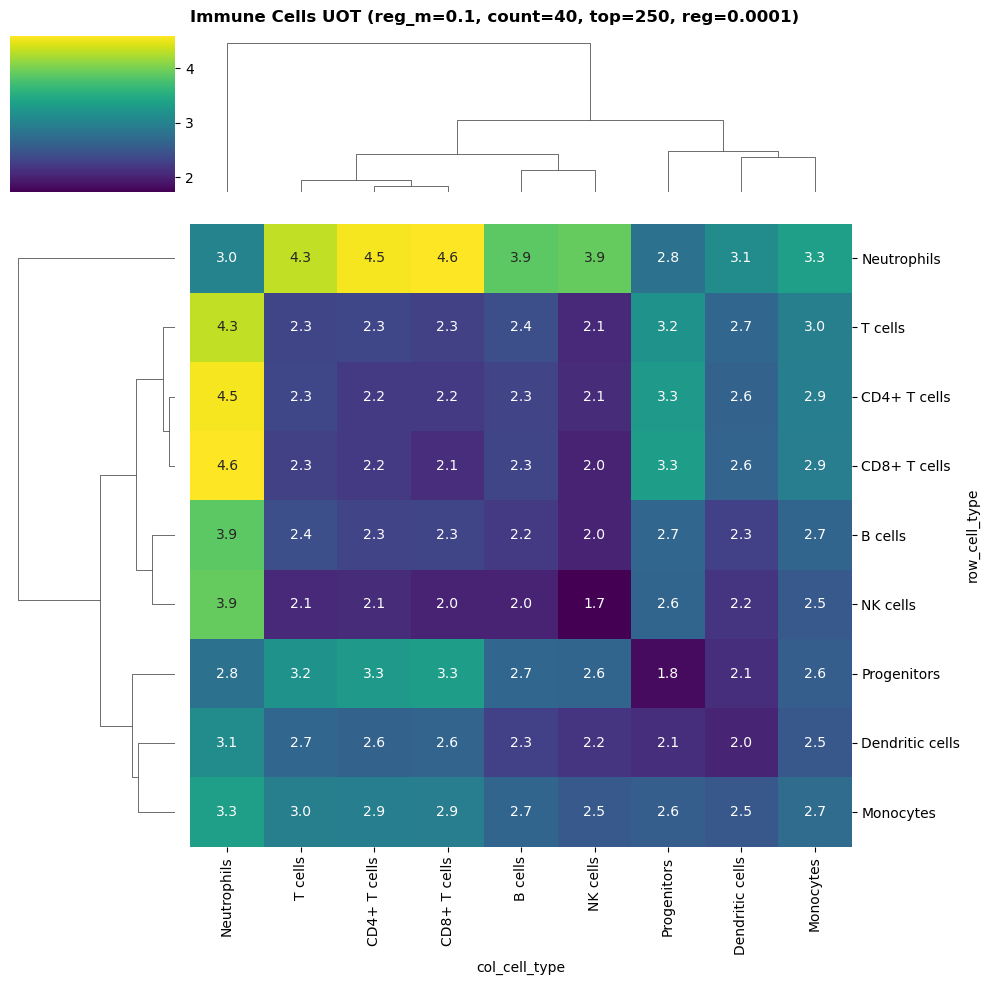

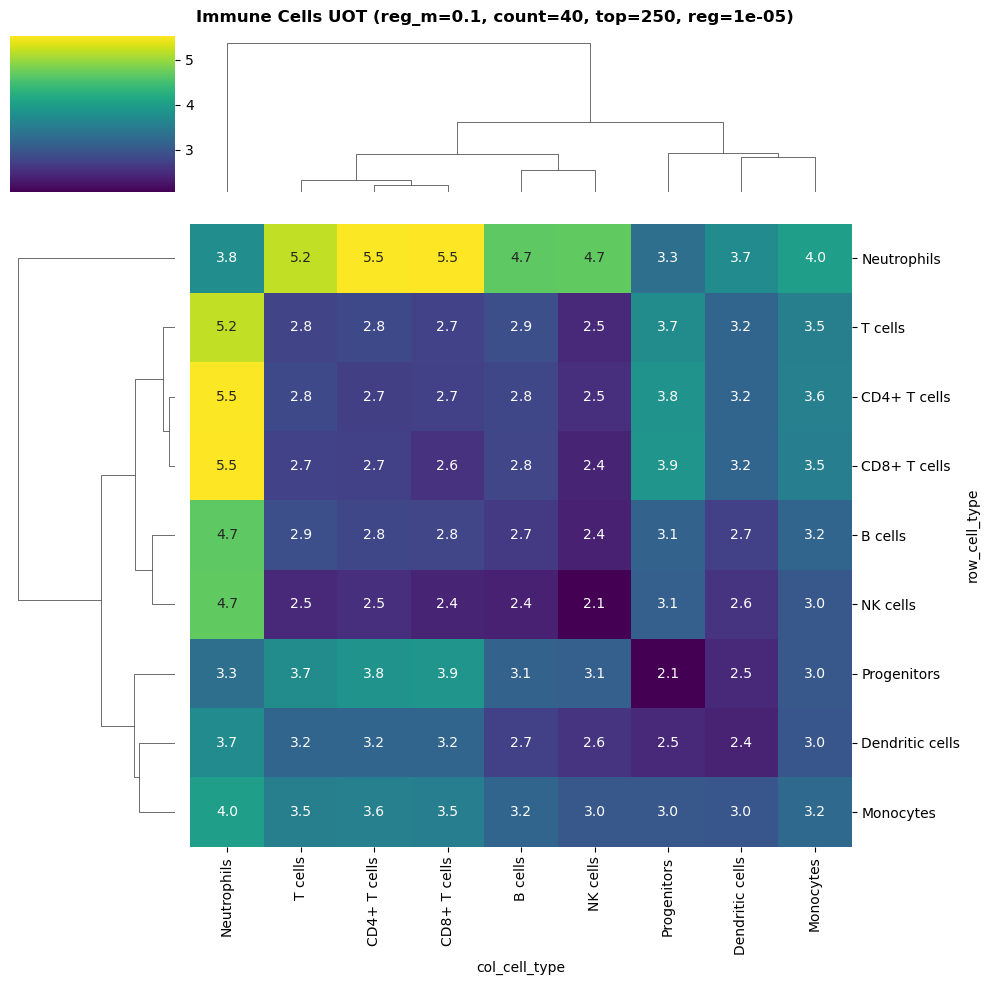

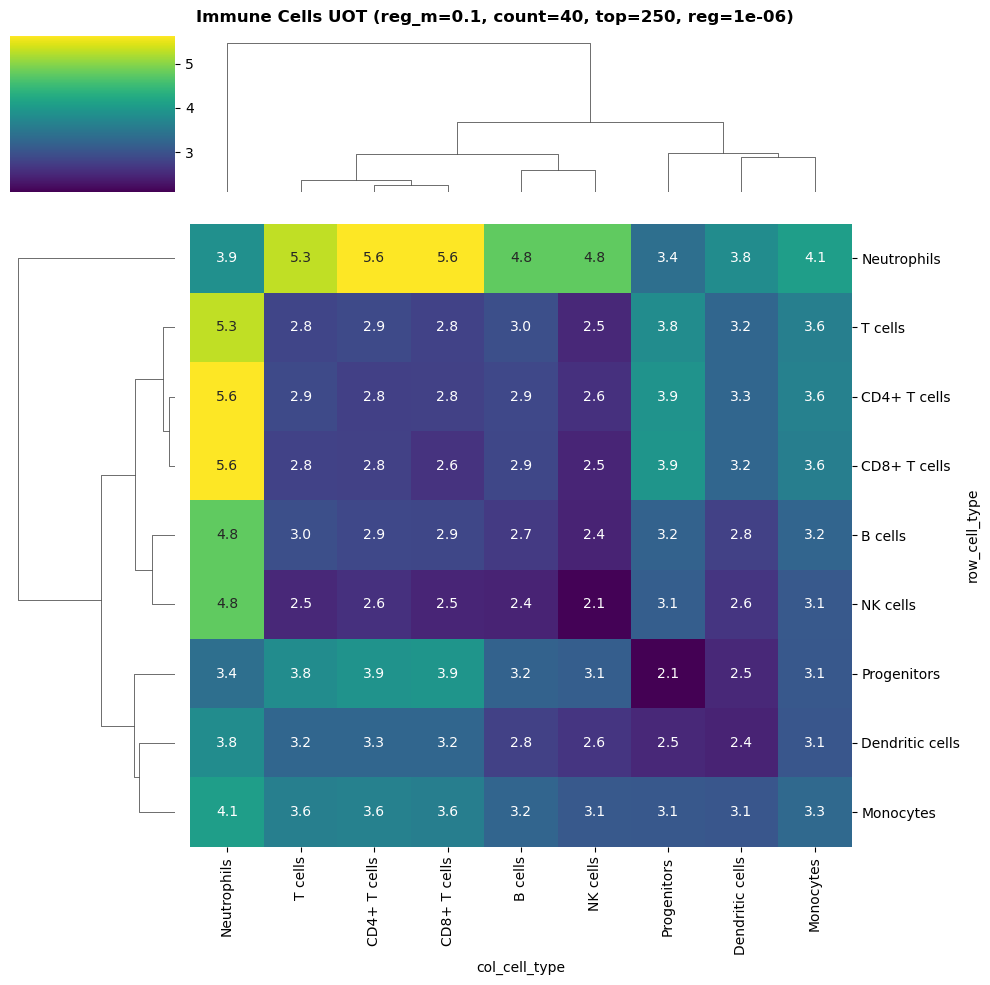

In [18]:
### Generating Clustermaps ###
for reg, data_long in zip(reg_list, data_long_list):
    title = f"Immune Cells UOT (reg_m=0.1, count=40, top=250, reg={reg})"
    generate_clustermap(data_long, title)

We can see that there is still a clear lymphoid block, even for the regularized OT variants.

### Marginal Plots

In [21]:
### Extracting Mass ###
total_masses = []
for reg in reg_list:
    file_name = f"{save_dir}/IMMUNE_CELLS_DEVIANCE_unbalanced_reg_m=0.1_cluster_top=250_count=40_seed=42_reg={reg}.csv"
    mass_df = pd.read_csv(file_name, index_col=0)
    total_masses.append(ot_mass_deviance(
        subset_clr_data(data_dir, metadata_df, 40, 42),
        "chr1",
        250,
        "max"
    ))

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_44177/603732694.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_44177/603732694.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_44177/603732694.py:35: FutureWarning: DataFrameGrou

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/hicotenv/lib/pyth

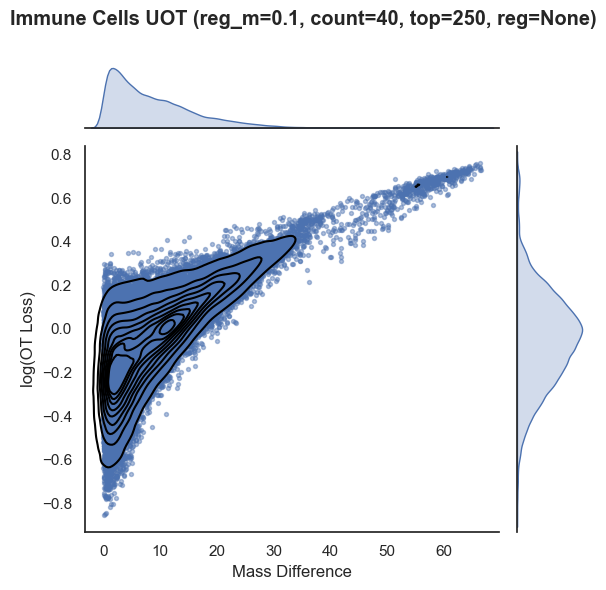

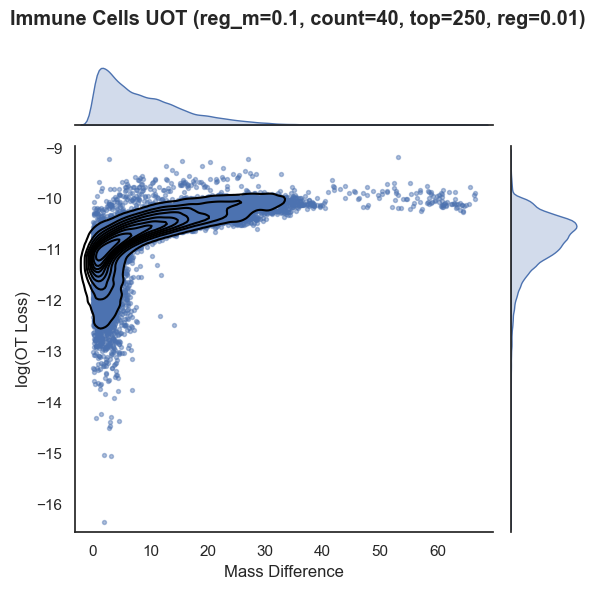

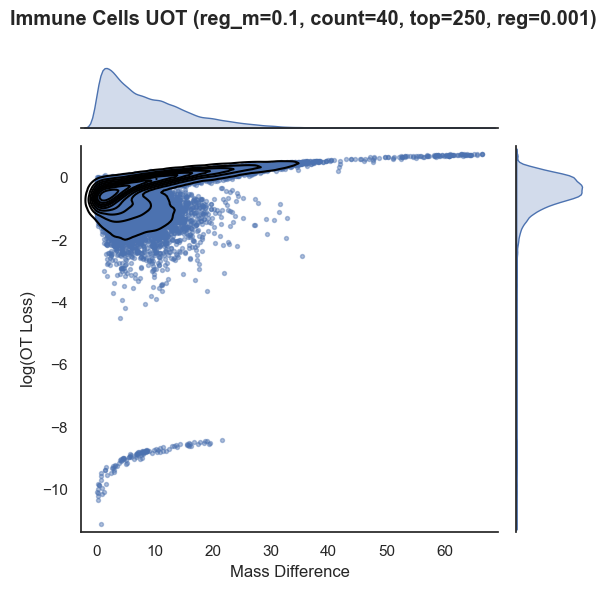

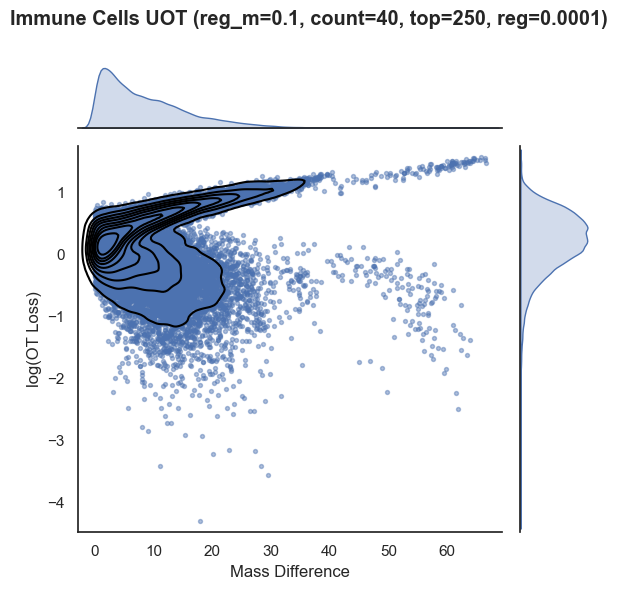

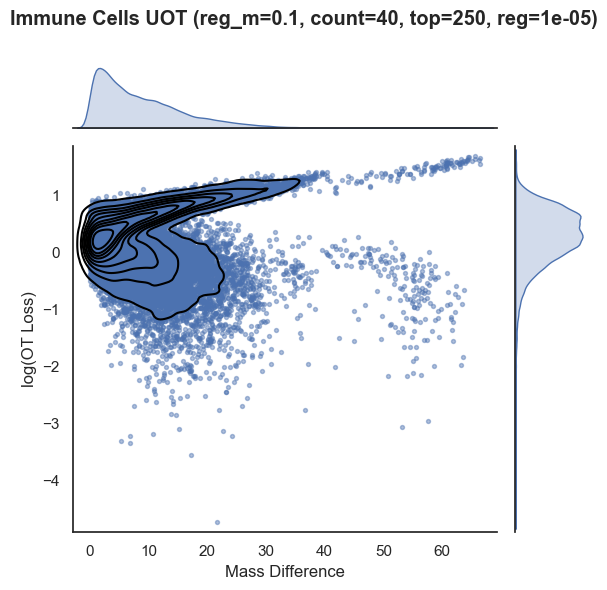

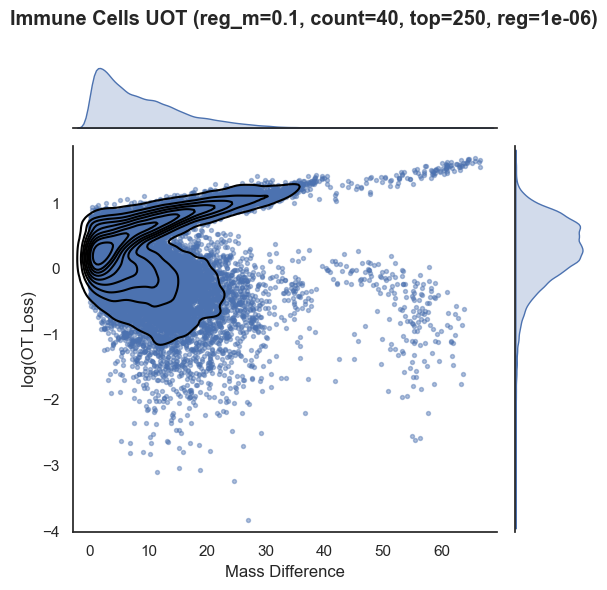

In [24]:
### Generating Marignal Plots ###
for reg, data_long, mass_df in zip(reg_list, data_long_list, total_masses):
    title = f"Immune Cells UOT (reg_m=0.1, count=40, top=250, reg={reg})"
    generate_marginal_plot(data_long, mass_df, title)

The marginal plots are a bit more different between regularized and non-regularized OT. 